In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("VAAC-Tiny Fusion Development")
print("Step 187")

VAAC-Tiny Fusion Development
Step 187


In [2]:
CLASS_NAMES = [
    "Healthy",
    "Ball",
    "Inner Race",
    "Outer Race"
]

CLASS_TO_INDEX = {
    name: i for i, name in enumerate(CLASS_NAMES)
}

print("Classes:")
for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)

Classes:
0 -> Healthy
1 -> Ball
2 -> Inner Race
3 -> Outer Race


In [3]:
BPFI_MULT = 5.4152
BPFO_MULT = 3.5848
FTF_MULT = 0.39828
RE_MULT = 4.7135

print("Bearing frequency multipliers:")
print("BPFI:", BPFI_MULT)
print("BPFO:", BPFO_MULT)
print("FTF :", FTF_MULT)
print("RE  :", RE_MULT)

Bearing frequency multipliers:
BPFI: 5.4152
BPFO: 3.5848
FTF : 0.39828
RE  : 4.7135


In [4]:
def calculate_physics_evidence(
    bpfi_energy,
    bpfo_energy,
    re_energy,
    healthy_score
):
    """
    Convert bearing-related spectral evidence into
    class-aligned physics evidence.

    Output order:
    Healthy, Ball, Inner Race, Outer Race
    """

    evidence = np.array([
        healthy_score,
        re_energy,
        bpfi_energy,
        bpfo_energy
    ], dtype=float)

    return evidence

In [5]:
physics_example = calculate_physics_evidence(
    bpfi_energy=0.80,
    bpfo_energy=0.15,
    re_energy=0.10,
    healthy_score=0.20
)

print(physics_example)

[0.2  0.1  0.8  0.15]


In [6]:
def normalize_physics_evidence(evidence):
    evidence = np.asarray(evidence, dtype=float)

    total = np.sum(evidence)

    if total <= 0:
        return np.ones_like(evidence) / len(evidence)

    return evidence / total
physics_probability = normalize_physics_evidence(
    physics_example
)

print(physics_probability)
print("Sum:", np.sum(physics_probability))

[0.16 0.08 0.64 0.12]
Sum: 1.0


In [7]:
def fuse_predictions(cnn_probabilities,
                     physics_probabilities,
                     cnn_weight=0.7,
                     physics_weight=0.3):

    if not np.isclose(cnn_weight + physics_weight, 1.0):
        raise ValueError("Weights must sum to 1.")

    cnn_probabilities = np.asarray(cnn_probabilities, dtype=float)
    physics_probabilities = np.asarray(
        physics_probabilities,
        dtype=float
    )

    fused_scores = (
        cnn_weight * cnn_probabilities
        + physics_weight * physics_probabilities
    )

    return fused_scores

In [8]:
cnn_prediction = np.array([
    0.05,  # Healthy
    0.10,  # Ball
    0.70,  # Inner Race
    0.15   # Outer Race
])

fused_prediction = fuse_predictions(
    cnn_prediction,
    physics_probability,
    cnn_weight=0.7,
    physics_weight=0.3
)

print("CNN prediction:")
for name, value in zip(CLASS_NAMES, cnn_prediction):
    print(f"{name:12s}: {value:.4f}")

print("\nPhysics evidence:")
for name, value in zip(CLASS_NAMES, physics_probability):
    print(f"{name:12s}: {value:.4f}")

print("\nFused prediction:")
for name, value in zip(CLASS_NAMES, fused_prediction):
    print(f"{name:12s}: {value:.4f}")

CNN prediction:
Healthy     : 0.0500
Ball        : 0.1000
Inner Race  : 0.7000
Outer Race  : 0.1500

Physics evidence:
Healthy     : 0.1600
Ball        : 0.0800
Inner Race  : 0.6400
Outer Race  : 0.1200

Fused prediction:
Healthy     : 0.0830
Ball        : 0.0940
Inner Race  : 0.6820
Outer Race  : 0.1410


In [9]:
final_index = np.argmax(fused_prediction)
final_class = CLASS_NAMES[final_index]

print("Final VAAC-Tiny decision:", final_class)

Final VAAC-Tiny decision: Inner Race


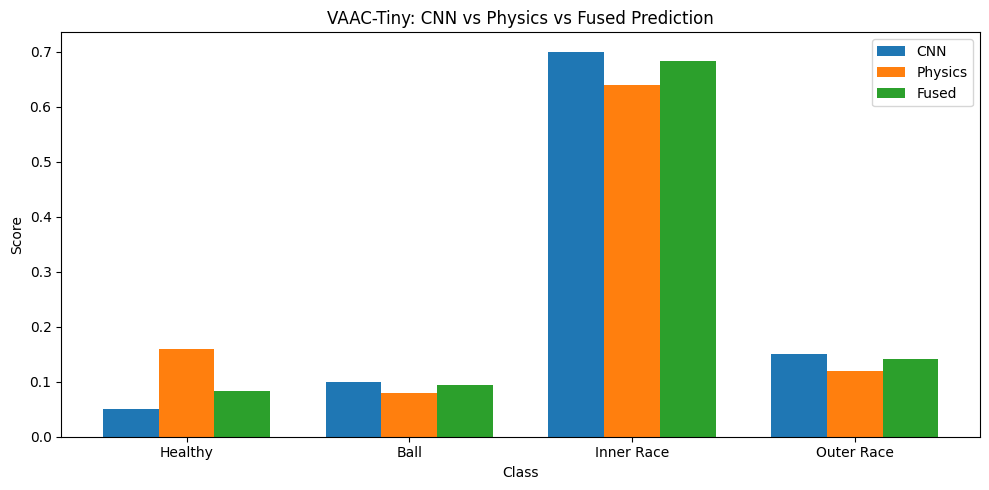

In [10]:
x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    cnn_prediction,
    width,
    label="CNN"
)

plt.bar(
    x,
    physics_probability,
    width,
    label="Physics"
)

plt.bar(
    x + width,
    fused_prediction,
    width,
    label="Fused"
)

plt.xticks(x, CLASS_NAMES)
plt.ylabel("Score")
plt.xlabel("Class")
plt.title("VAAC-Tiny: CNN vs Physics vs Fused Prediction")
plt.legend()
plt.tight_layout()
plt.show()